<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentNvidia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [3]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [5]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [6]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [7]:
nvda_df = df[df["symbols"].str.contains("NVDA.US", na=False)].copy()

print("Broj NVDA.US vesti:", len(nvda_df))

Broj NVDA.US vesti: 1413


In [8]:
nvda_df.to_csv("/content/drive/MyDrive/nvda_news.csv", index=False)

In [9]:
nvda_df["year"] = pd.to_datetime(nvda_df["date"]).dt.year
nvda_df["year"].value_counts().sort_index()

,count
year,
2017,1
2020,6
2021,268
2022,234
2023,453
2024,451


In [10]:
random_news = nvda_df.sample(1)

print("DATUM:", random_news["date"].values[0])
print("NASLOV:", random_news["title"].values[0])
print("TEKST:", random_news["content"].values[0])

DATUM: 2024-06-26T11:50:35.000000000
NASLOV: What's Going On With Taiwan Semi Stock On Wednesday?
TEKST: What's Going On With Taiwan Semi Stock On Wednesday?

Analysts on Tuesday said that Taiwan’s Semiconductor Industry should maintain its global lead for at least the next eight to ten years.

They urged the government to ensure the country’s research security and develop a “grand strategy” considering changing supply chains.

Taiwan Semiconductor Manufacturing Co (NYSE:TSM), headquartered in Taiwan, led global foundry revenue in the first quarter. It is a crucial supplier of Nvidia Corp and Apple Inc (NASDAQ:AAPL).

Also Read: What’s Going On With Taiwan Semi Stock On Tuesday?

China’s state-backed Semiconductor Manufacturing International Co TSMC held a 62% market share in the first quarter.

At a forum called “Taiwan in the era of techno-geopolitics” in Taipei hosted by the new think tank Research Institute for Democracy, Society, and Emerging Technology (DSET), veteran analyst Ray

In [11]:
!pip install yfinance

In [12]:
import yfinance as yf
import pandas as pd

In [13]:
import yfinance as yf

nvda_prices = yf.download("NVDA", start="2017-01-01", end="2024-12-31")

nvda_prices = nvda_prices.reset_index()

nvda_prices = nvda_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_16451/831713092.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda_prices = yf.download("NVDA", start="2017-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [14]:
nvda_df["date"] = pd.to_datetime(nvda_df["date"]).dt.date
nvda_prices["date"] = pd.to_datetime(nvda_prices["date"]).dt.date

nvda_df["date"] = pd.to_datetime(nvda_df["date"])
nvda_prices["date"] = pd.to_datetime(nvda_prices["date"])

nvda_df = nvda_df.sort_values("date")
nvda_prices = nvda_prices.sort_values("date")

nvda_prices.columns = nvda_prices.columns.droplevel(1)
nvda_prices = nvda_prices.rename(columns={"Close": "close"})

In [15]:
import pandas as pd

# 1) priprema price tabele
nvda_prices = nvda_prices.sort_values("date").copy()
nvda_prices["close_t"] = nvda_prices["close"]
nvda_prices["close_t1"] = nvda_prices["close"].shift(-1)
nvda_prices["open_t1"] = nvda_prices["Open"].shift(-1)
nvda_prices["open_t2"] = nvda_prices["Open"].shift(-2)

nvda_prices["avg_t"] = (
    nvda_prices["Open"] +
    nvda_prices["High"] +
    nvda_prices["Low"] +
    nvda_prices["close"]
) / 4

nvda_prices["avg_t1"] = nvda_prices["avg_t"].shift(-1)

# 2) merge vesti, sledeći trading dan
nvda_merged = pd.merge_asof(
    nvda_df.sort_values("date"),
    nvda_prices[["date", "close_t", "close_t1", "open_t1", "open_t2", "avg_t", "avg_t1"]],
    on="date",
    direction="forward"
)

# 3) prinosi

# close-close: od današnjeg close do sutrašnjeg close
nvda_merged["return_close_close"] = (
    nvda_merged["close_t1"] - nvda_merged["close_t"]
) / nvda_merged["close_t"]

# open-close: od sutrašnjeg open do sutrašnjeg close
nvda_merged["return_open_close"] = (
    nvda_merged["close_t1"] - nvda_merged["open_t1"]
) / nvda_merged["open_t1"]

# open-open: od sutrašnjeg open do preksutrašnjeg open
nvda_merged["return_open_open"] = (
    nvda_merged["open_t2"] - nvda_merged["open_t1"]
) / nvda_merged["open_t1"]

# avg-avg
nvda_merged["return_avg_avg"] = (
    nvda_merged["avg_t1"] - nvda_merged["avg_t"]
) / nvda_merged["avg_t"]

In [16]:
nvda_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2017-11-27,"Factors of Influence in 2018, Key Indicators a...",5.293899,5.209105,-0.016017,-0.020247,-0.016982,-0.017141
1,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,7.772027,7.749617,-0.002883,-0.009567,-0.017367,-0.016321
2,2020-08-07,How to Trade Nvidia as It Shatters Another Rec...,11.160851,11.126470,-0.003080,-0.022984,-0.014933,-0.006442
3,2020-09-03,PREMIUM: Trading volatile markets during prime...,12.974463,12.582704,-0.030195,-0.082077,-0.012614,-0.061960
4,2020-09-08,Inverse Tech ETFs Jump as Traders Book Profits,11.875442,12.674913,0.067321,0.047520,0.025403,0.047060


In [17]:
d = pd.to_datetime("2021-07-28")

nvda_merged[nvda_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
172,19.458426,19.617062


In [18]:
nvda_merged["direction_close_close"] = nvda_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

nvda_merged["direction_open_open"] = nvda_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

nvda_merged["direction_open_close"] = nvda_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

nvda_merged["direction_avg_avg"] = nvda_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [19]:
nvda_merged["direction_close_close"].value_counts()

,count
direction_close_close,
UP,743
DOWN,670


In [20]:
nvda_merged["direction_open_open"].value_counts()

,count
direction_open_open,
UP,803
DOWN,610


In [21]:
nvda_merged["direction_open_close"].value_counts()

,count
direction_open_close,
UP,729
DOWN,684


In [22]:
nvda_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
UP,755
DOWN,658


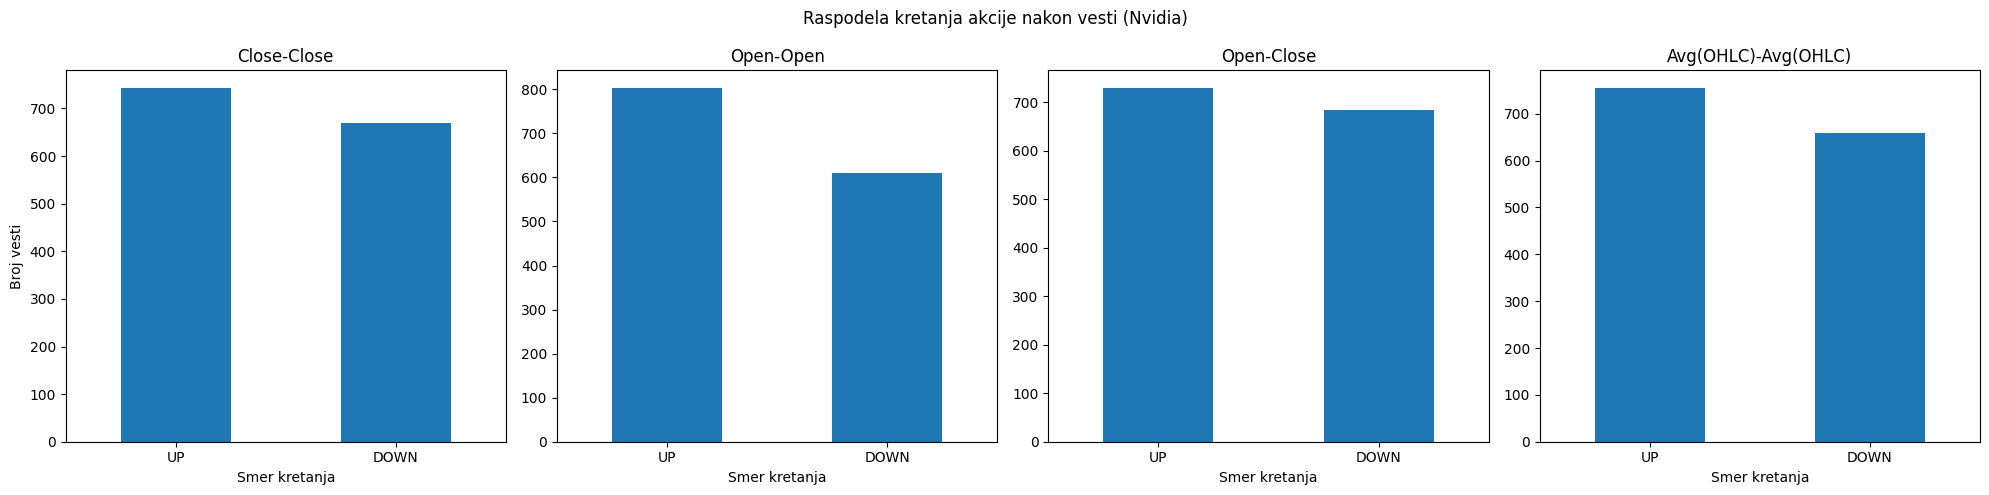

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
nvda_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open
nvda_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
nvda_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
nvda_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Nvidia)")

plt.tight_layout()
plt.show()

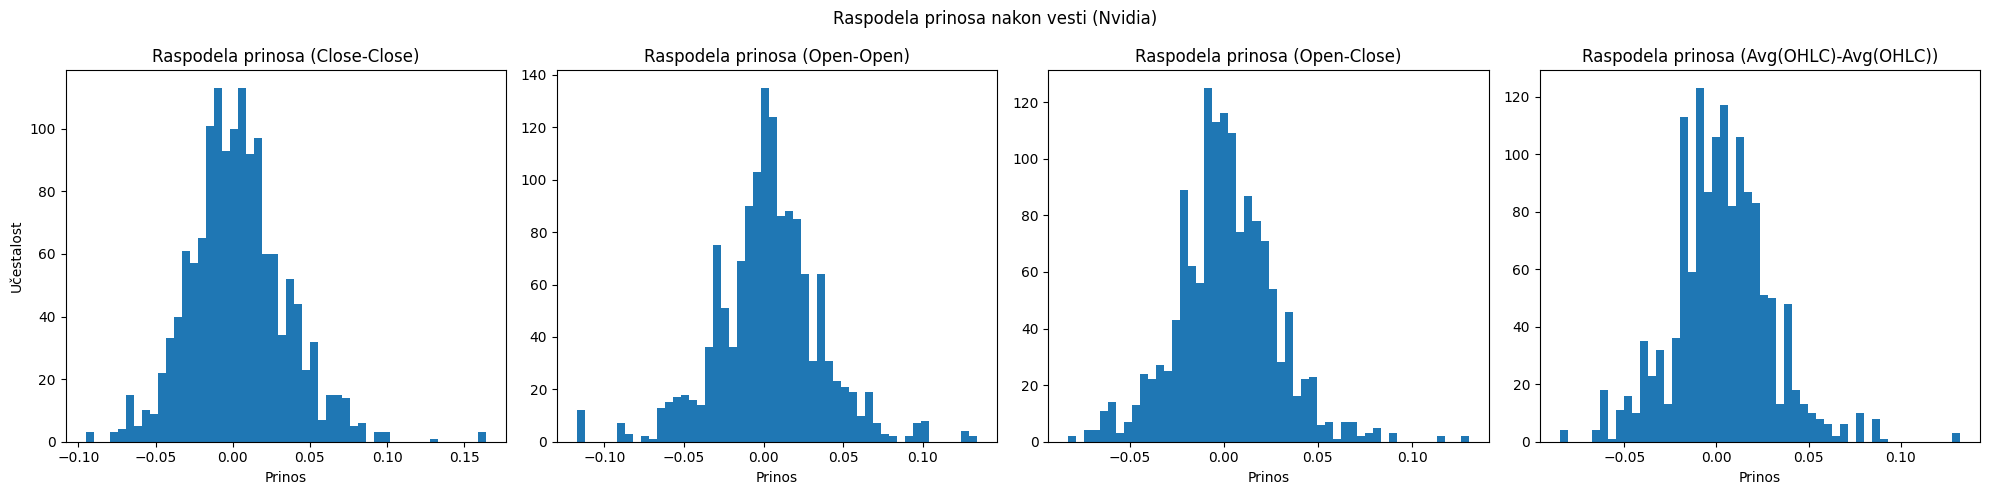

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(nvda_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(nvda_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(nvda_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(nvda_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Nvidia)")

plt.tight_layout()
plt.show()

In [25]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [27]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    AI = "ai_ml"
    GPUS = "gpu_hardware"
    DATA_CENTER = "data_center_infrastructure"
    GAMING = "gaming_graphics"
    AUTOMOTIVE = "autonomous_driving"
    SEMICONDUCTORS = "semiconductor_industry"
    SUPPLY_CHAIN = "supply_chain_production"
    REGULATION = "regulation_antitrust"
    LEGAL = "legal_lawsuit"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Nvidia-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Nvidia in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Nvidia. Choose the closest single category.",
        examples=[Topic.AI]
    )

In [28]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


nvda_merged["text_for_ie"] = nvda_merged.apply(combine_title_content, axis=1)

nvda_merged[["text_for_ie"]].head(2)

,text_for_ie
0,"TITLE: Factors of Influence in 2018, Key Indic..."
1,TITLE: Not Just Fun And Games: How Esports Cou...


In [29]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 12.5 MB/s eta 0:00:00


In [32]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Nvidia-targeted sentiment based on the impact on NVIDIA Corporation (Nvidia, NVDA).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Nvidia
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Nvidia is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Nvidia is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Nvidia-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [33]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Nvidia kompaniju.
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    # FINALNO ČUVANJE
    if save_path:
        out.to_csv(save_path, index=False)
        print(f"Final save completed: {save_path}")

    return out

In [34]:
nvda_tagged = tag_df_openai(
    nvda_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/nvda_news_tagged.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Final save completed: /content/drive/MyDrive/nvda_news_tagged.csv


In [35]:
nvda_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_open',
       'direction_open_close', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic'],
      dtype='object')

In [36]:
nvda_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2017-11-27,"Factors of Influence in 2018, Key Indicators a...",neutral,0.0,other
1,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,neutral,0.0,gaming_graphics
2,2020-08-07,How to Trade Nvidia as It Shatters Another Rec...,positive,0.9,semiconductor_industry
3,2020-09-03,PREMIUM: Trading volatile markets during prime...,neutral,0.0,other
4,2020-09-08,Inverse Tech ETFs Jump as Traders Book Profits,neutral,0.0,other
5,2020-09-17,INSIGHT-The Musk Method: Learn from partners t...,neutral,0.0,other
6,2020-09-17,INSIGHT-The Musk Method: Learn from partners t...,neutral,0.0,other
7,2021-01-08,"The Best Mutual Funds Bet These Tech Stocks, I...",positive,0.7,other
8,2021-01-15,Hot DWS Fund Defends Apple's Sluggish Sales Gr...,neutral,0.0,other
9,2021-02-14,15 Best Momentum Stocks to Buy Now,neutral,0.0,other


In [37]:
nvda_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,785
positive,463
negative,165


In [38]:
nvda_tagged["sentiment_score"].describe()

,sentiment_score
count,1413.000000
mean,0.164473
std,0.428513
min,-0.900000
25%,0.000000
50%,0.000000
75%,0.700000
max,0.900000


In [39]:
nvda_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,neutral,0.0
1,neutral,0.0
2,positive,0.9
3,neutral,0.0
4,neutral,0.0
5,neutral,0.0
6,neutral,0.0
7,positive,0.7
8,neutral,0.0
9,neutral,0.0


In [40]:
nvda_tagged["date_only"] = pd.to_datetime(nvda_tagged["date"]).dt.date

In [41]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

nvda_tagged["sentiment_num"] = nvda_tagged["sentiment"].map(sent_map)

In [42]:
daily_sentiment_class = nvda_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [43]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2017-11-27,0.000000,1
1,2020-05-12,0.000000,1
2,2020-08-07,1.000000,1
3,2020-09-03,0.000000,1
4,2020-09-08,0.000000,1
5,2020-09-17,0.000000,2
6,2021-01-08,1.000000,1
7,2021-01-15,0.000000,1
8,2021-02-14,0.000000,1
9,2021-02-23,0.000000,1


In [44]:
daily_sentiment_score = nvda_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [45]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2017-11-27,0.0,1
1,2020-05-12,0.0,1
2,2020-08-07,0.9,1
3,2020-09-03,0.0,1
4,2020-09-08,0.0,1
5,2020-09-17,0.0,2
6,2021-01-08,0.7,1
7,2021-01-15,0.0,1
8,2021-02-14,0.0,1
9,2021-02-23,0.0,1


In [46]:
daily_sentiment = nvda_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [49]:
d = pd.to_datetime("2023-11-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]

,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
474,2023-11-03,0.0,0.0,1,0.016576,0.01029,0.009584,0.021414


In [50]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_16451/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,-0.003614,0.000280,0.001121,-0.005709
neutral,0.005596,0.002278,0.003983,0.005305
positive,0.002626,0.001929,0.004410,0.002592


In [51]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,-0.000094,0.004498,0.004313,-0.005652
neutral,0.005689,0.002305,0.003903,0.005434
positive,0.002629,0.001951,0.004514,0.002580


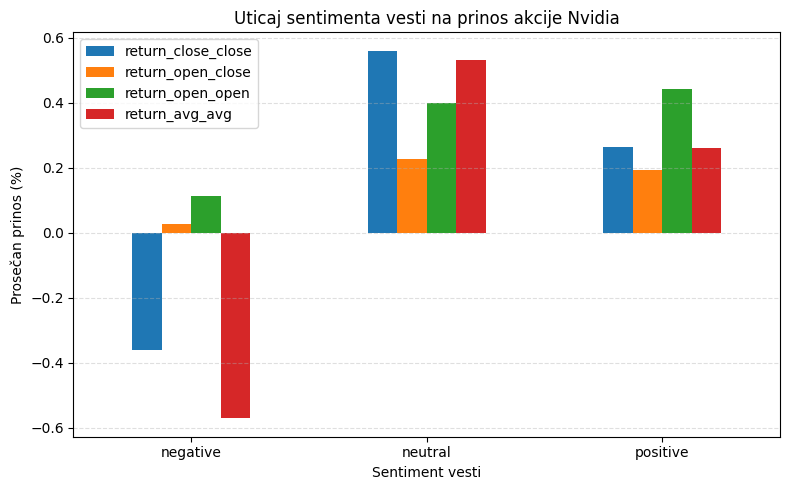

In [52]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Nvidia")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

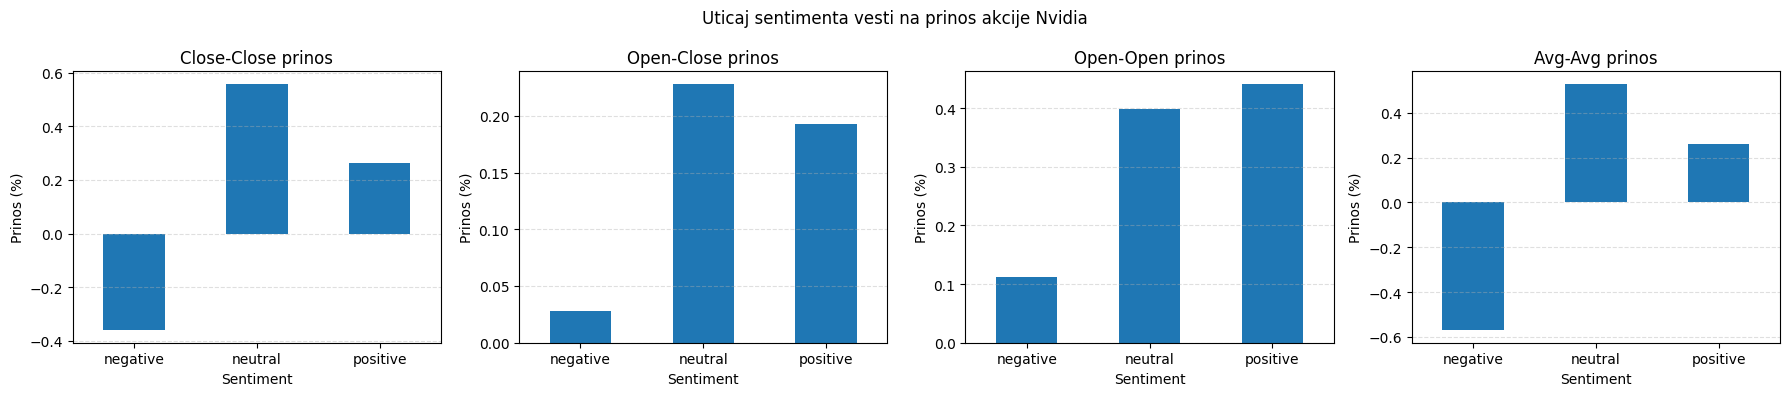

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Nvidia")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

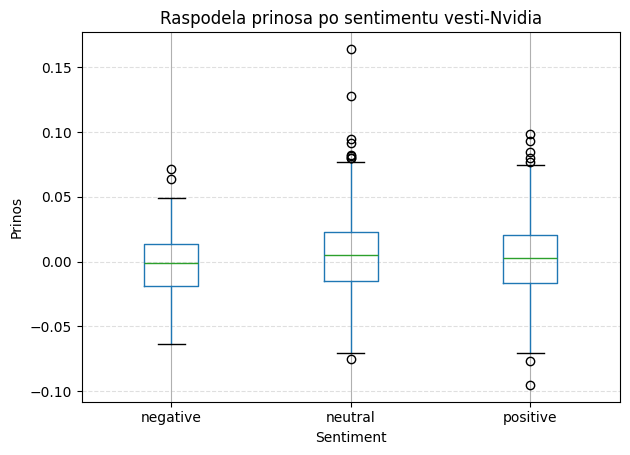

In [54]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti-Nvidia")
plt.suptitle("")  # uklanja default naslov
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

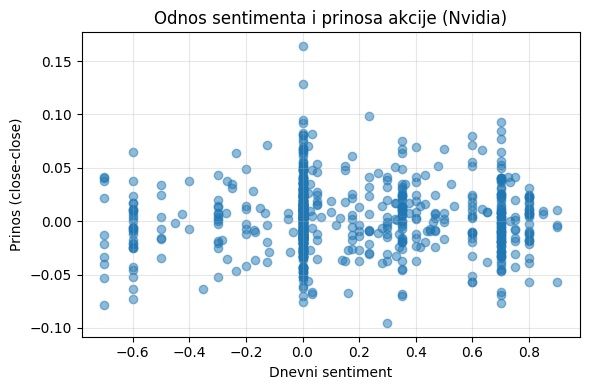

In [55]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Nvidia)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()